## Task 5: Strategy Backtesting

### 0. Load Historical Data and Recommended Portfolio Weights

We reload the historical price data and hard-code the Max Sharpe Ratio
portfolio weights identified in Task 4 (36.73% TSLA, 0.00% BND, 63.27%
SPY), which will be simulated against a static 60% SPY / 40% BND
benchmark over the backtesting period.

In [1]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    combined_df = pd.read_csv('../data/processed/combined_assets.csv', parse_dates=['Date'])
    tickers = ['TSLA', 'BND', 'SPY']

    price_wide = combined_df.pivot(index='Date', columns='Ticker', values='Adj Close')
    price_wide = price_wide[tickers].dropna()

    strategy_weights = {'TSLA': 0.36728, 'BND': 0.0, 'SPY': 0.63272}
    benchmark_weights = {'TSLA': 0.0, 'BND': 0.40, 'SPY': 0.60}

    print(price_wide.tail())
except Exception as e:
    print(f"Error loading data or setting weights: {e}")

Ticker            TSLA        BND         SPY
Date                                         
2026-06-23  381.609985  72.976631  733.580017
2026-06-24  375.529999  73.305534  733.239990
2026-06-25  375.119995  73.355370  734.299988
2026-06-26  379.709991  73.425133  728.989990
2026-06-29  411.839996  73.465004  741.000000


### 1. Define Backtesting Period

Per the project brief, we use the last year of available data — January
2025 through the end of the dataset (June 2026) — as the backtesting
window. This data was excluded from LSTM training in Task 2 (which
trained only on 2015-2024), so it represents a genuine out-of-sample test
of the strategy.

In [2]:
try:
    backtest_start = '2025-01-01'
    backtest_df = price_wide[price_wide.index >= backtest_start].copy()

    print(f"Backtest period: {backtest_df.index.min()} to {backtest_df.index.max()}")
    print(f"Number of trading days: {len(backtest_df)}")
except Exception as e:
    print(f"Error defining backtest period: {e}")

Backtest period: 2025-01-02 00:00:00 to 2026-06-29 00:00:00
Number of trading days: 372


### 2. Simulate Strategy Portfolio (Monthly Rebalancing)

We simulate the strategy portfolio starting with $10,000, rebalancing
back to the target weights (36.73% TSLA / 63.27% SPY) at the start of
each month. Monthly rebalancing is more realistic than a simple buy-and-
hold, since it reflects how GMF would actually manage a live portfolio
mandate over time, and prevents any single asset's drift from silently
concentrating risk.

In [4]:
try:
    initial_capital = 10000

    daily_returns = backtest_df.pct_change().dropna()

    def simulate_portfolio(returns_df, weights_dict, initial_capital, rebalance='ME'):
        weights = np.array([weights_dict[t] for t in returns_df.columns])
        portfolio_value = [initial_capital]
        current_weights = weights.copy()
        holdings_value = initial_capital * current_weights

        rebalance_dates = returns_df.resample(rebalance).first().index

        for date, row in returns_df.iterrows():
            holdings_value = holdings_value * (1 + row.values)
            total_value = holdings_value.sum()

            if date in rebalance_dates:
                holdings_value = total_value * weights

            portfolio_value.append(total_value)

        return pd.Series(portfolio_value[1:], index=returns_df.index)

    strategy_value = simulate_portfolio(daily_returns, strategy_weights, initial_capital)
    print(strategy_value.head())
    print(strategy_value.tail())
except Exception as e:
    print(f"Error simulating strategy portfolio: {e}")

Date
2025-01-03    10380.853570
2025-01-06    10423.664728
2025-01-07    10189.210159
2025-01-08    10204.134019
2025-01-10    10104.796414
dtype: float64
Date
2026-06-23    12021.214142
2026-06-24    11948.342668
2026-06-25    11954.752092
2026-06-26    11951.557799
2026-06-29    12443.443251
dtype: float64


### 3. Simulate Benchmark Portfolio (60% SPY / 40% BND)

The benchmark uses the same monthly rebalancing logic, applied to the
static 60/40 SPY/BND allocation — a standard, widely used balanced
portfolio construction used as a passive comparison point.

In [5]:
try:
    benchmark_value = simulate_portfolio(daily_returns, benchmark_weights, initial_capital)
    print(benchmark_value.head())
    print(benchmark_value.tail())
except Exception as e:
    print(f"Error simulating benchmark portfolio: {e}")

Date
2025-01-03    10070.016405
2025-01-06    10101.120695
2025-01-07    10018.151719
2025-01-08    10031.426400
2025-01-10     9918.489377
dtype: float64
Date
2026-06-23    11945.205388
2026-06-24    11963.081905
2026-06-25    11976.752589
2026-06-26    11928.887238
2026-06-29    12049.906279
dtype: float64


### 4. Visualize Cumulative Returns: Strategy vs. Benchmark

Plotting both portfolios' value over the backtest period on the same
axis makes it easy to see whether the model-driven strategy actually
outperformed the passive benchmark, and how the two diverged over time.

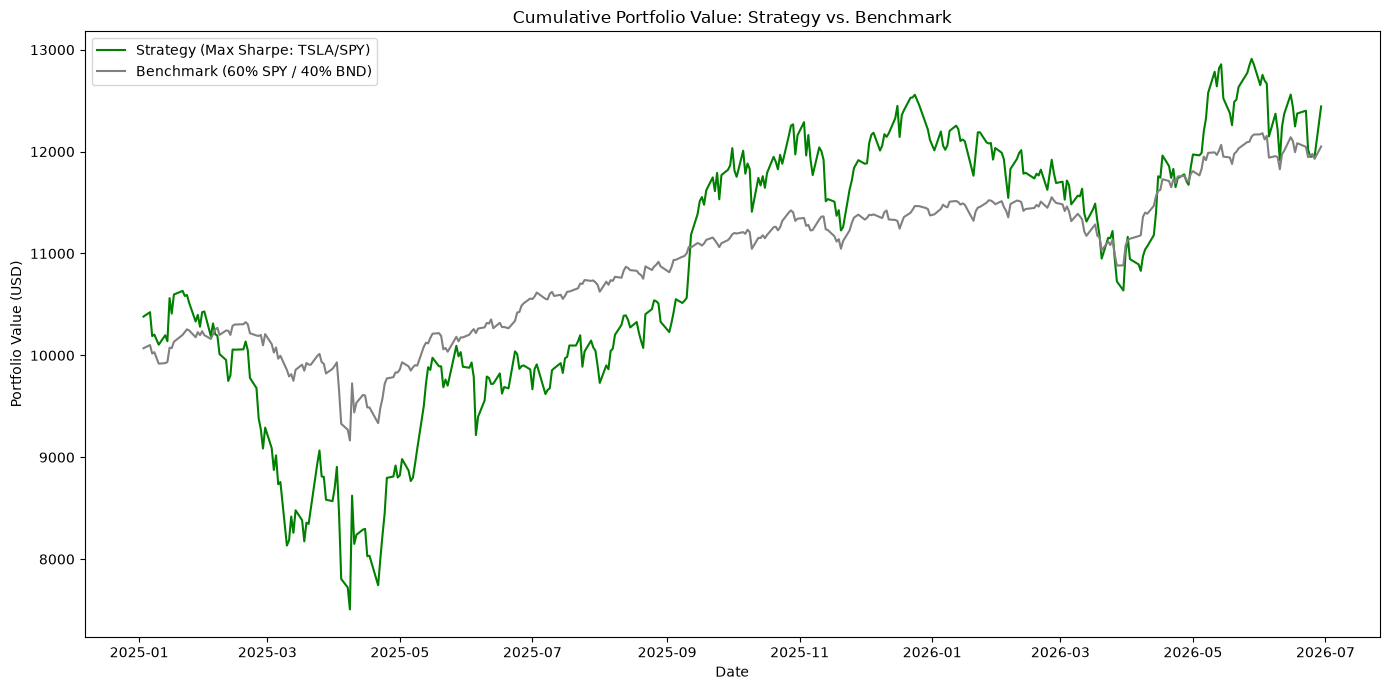

In [6]:
try:
    plt.figure(figsize=(14, 7))
    plt.plot(strategy_value.index, strategy_value.values, label='Strategy (Max Sharpe: TSLA/SPY)', color='green')
    plt.plot(benchmark_value.index, benchmark_value.values, label='Benchmark (60% SPY / 40% BND)', color='gray')
    plt.title('Cumulative Portfolio Value: Strategy vs. Benchmark')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting cumulative returns comparison: {e}")

### 5. Calculate Performance Metrics

We compute four standard metrics for both portfolios:
- **Total Return**: overall percentage gain/loss over the backtest period
- **Annualized Return**: total return scaled to a yearly rate
- **Sharpe Ratio**: risk-adjusted return
- **Maximum Drawdown**: the largest peak-to-trough decline, a key measure
  of downside risk during the holding period

In [7]:
try:
    def calculate_performance_metrics(portfolio_value, risk_free_rate=0.02, trading_days=252):
        returns = portfolio_value.pct_change().dropna()

        total_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) - 1

        n_days = len(portfolio_value)
        annualized_return = (1 + total_return) ** (trading_days / n_days) - 1

        annualized_vol = returns.std() * np.sqrt(trading_days)
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol

        cumulative = portfolio_value / portfolio_value.iloc[0]
        running_max = cumulative.cummax()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()

        return {
            'Total Return': total_return,
            'Annualized Return': annualized_return,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown
        }

    strategy_metrics = calculate_performance_metrics(strategy_value)
    benchmark_metrics = calculate_performance_metrics(benchmark_value)

    metrics_comparison = pd.DataFrame({
        'Strategy': strategy_metrics,
        'Benchmark': benchmark_metrics
    })

    print(metrics_comparison)
except Exception as e:
    print(f"Error calculating performance metrics: {e}")

                   Strategy  Benchmark
Total Return       0.198692   0.196612
Annualized Return  0.130998   0.129665
Sharpe Ratio       0.374055   0.989805
Max Drawdown      -0.294056  -0.112484
